In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")
from Src.data_modules import *

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report,cohen_kappa_score, make_scorer, mean_squared_error, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.utils import shuffle, resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA, NMF

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_selection import f_classif

from joblib import dump, load

import statsmodels.api as sm

import shap

# Data Loading

## Train

In [2]:
X, y, data = get_training_input_data_channel_parallel()

Computing channel n°0
Computing channel n°1
Computing channel n°2
Computing channel n°3
Computing channel n°4
261755 windows to compute...


Parallel feature extraction: 100%|██████████| 261755/261755 [14:54<00:00, 292.60it/s]


In [3]:
X

,std,var,amplitude,skewness,kurtosis,min,max,mean,median,amplitude_speed,...,cov_with_others,euclidean_distance_with_others,NMF_mode_0,NMF_mode_1,NMF_mode_2,NMF_mode_3,NMF_mode_4,NMF_mode_5,NMF_mode_6,NMF_mode_7
0,7825.555520,6.123932e+07,29688.059102,1.003226,-0.184796,-7451.310123,22236.748979,-480.055757,-3879.684711,6907.867848,...,1.298848e+08,2.534439e+05,60.758658,145.524353,0.000000,0.000000,0.000000,13.183668,0.000000,0.001347
1,3451.014189,1.190950e+07,10334.807254,0.023730,-1.433863,-7303.856154,3030.951100,-2486.790790,-2371.494282,105.911262,...,2.186959e+07,1.227805e+05,0.000000,0.000000,12.175418,0.000000,0.000000,0.000000,0.000000,7.269862
2,492.931099,2.429811e+05,1771.651573,-0.684970,-0.669198,3039.582889,4811.234461,4245.956843,4359.037392,65.751110,...,4.442941e+05,1.185094e+05,126.830619,72.440042,52.951734,39.003063,19.612547,2.806904,3.880134,8.805059
3,1464.138378,2.143701e+06,4697.576701,0.151727,-1.302688,-1501.024522,3196.552179,726.247410,576.165839,46.265269,...,4.320343e+06,5.533832e+04,52.182331,42.727429,0.000000,2.397715,0.000000,2.581118,0.928183,0.000000
4,201.662656,4.066783e+04,840.036264,0.970873,-0.181173,-2361.369121,-1521.332857,-2124.679176,-2208.791908,50.397698,...,8.180331e+04,6.490656e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261750,25523.904669,6.514697e+08,88436.246320,0.504721,-0.976549,5012.165603,93448.411924,37979.619001,32289.977212,1073.167690,...,4.207478e+07,1.158444e+06,1421.019200,1161.200942,163.915352,227.741834,84.902430,71.999322,35.089540,15.051026
261751,15533.132687,2.412782e+08,96328.259642,0.769081,1.837086,-45569.741842,50758.517800,2359.974923,4239.815744,16686.128478,...,9.160130e+07,5.082711e+05,0.000000,333.676191,111.908634,175.890510,0.000000,3.540932,0.000000,10.801796
261752,2406.259828,5.790086e+06,9016.444927,-0.140763,-1.049870,4716.024482,13732.469408,9687.546696,9730.638794,933.088027,...,-4.650309e+06,2.925163e+05,227.313020,122.009217,155.392577,81.105960,47.122991,4.547813,7.020679,33.873587
261753,780.113399,6.085769e+05,3606.611050,-1.082377,0.398272,13130.833991,16737.445041,15498.202384,15690.506107,1134.092094,...,-1.922934e+05,4.426558e+05,434.341827,254.082029,202.135559,131.491897,69.301414,11.415496,12.692468,39.133730


In [ ]:
X.to_csv("X_all_data2.csv", index=False, sep=",")
y.to_csv("y_all_data.2csv", index=False, sep=",")

In [197]:
X = pd.read_csv("X_all_data.csv", sep=",")
y = pd.read_csv("y_all_data.csv", sep=",")

In [180]:
cols_to_drop = ["skewness", "corr_with_others", "hc", "hurst", "wv4", "apen", "std", "NMF_mode_0", "NMF_mode_1", "NMF_mode_4", "NMF_mode_6", "NMF_mode_5", "NMF_mode_7"]
X = X.drop(columns=cols_to_drop)

In [342]:
cols_to_drop = ["skewness", "corr_with_others", "hc", "hurst", "wv4", "apen", "std", "NMF_mode_0", "NMF_mode_1", "NMF_mode_4", "NMF_mode_6", "NMF_mode_5", "NMF_mode_7", "energy", "kurtosis", "pfd", "spen", "psd_beta", "zc", "pen" ,"NMF_mode_3"]
X = X.drop(columns=cols_to_drop)

In [59]:
cols_to_keep = ['renyi_entropy',
 'apen',
 'D3-4',
 'hm',
 'ha',
 'zc',
 'D4-4',
 'pfd',
 'D4-1',
 'D5-3',
 'D5-1',
 'D4-3',
 'hurst',
 'mcl',
 'pen',
 'D5-2',
 'spen']

X = X[cols_to_keep]

In [72]:
cols_to_keep = ["renyi_entropy", "apen", "zc", "pfd", "hurst", "mcl", "pen", "spen", "amplitude_speed", "euclidean_distance_with_others", "std"] #, "spen", "amplitude_speed", "euclidean_distance_with_others", "std"
X = X[cols_to_keep]

In [199]:
# 1. Charger et prétraiter les données
X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.3, random_state=42)

### NMF

In [36]:
all_windows = np.array(data["signal_windowed"].tolist())
all_windows = [[x if x >= 0 else 0 for x in arr] for arr in all_windows]

1
2
3
4
5
6
7
8
9


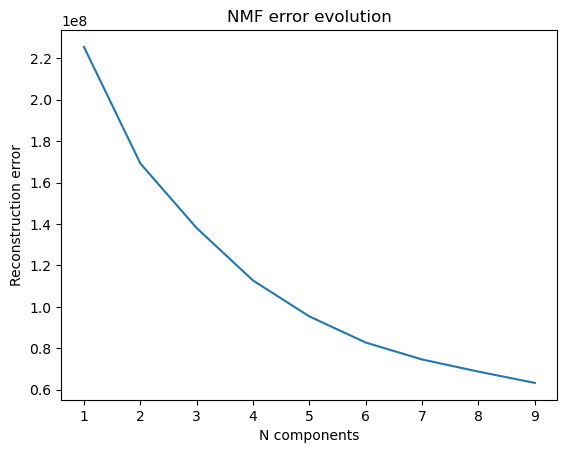

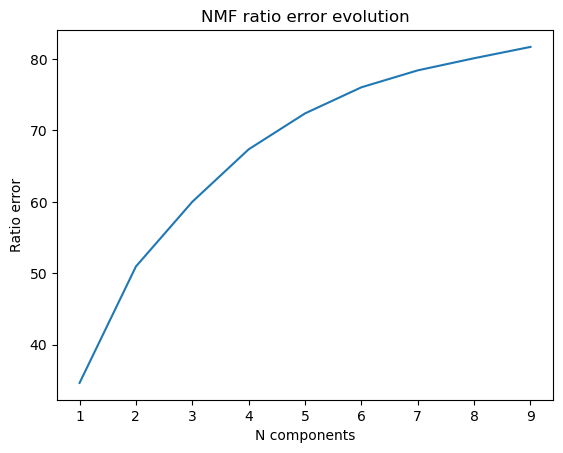

In [37]:
n_range = 10
errors = []
ratios = []

for n in range(1, n_range):
    print(n)
    model = NMF(n_components=n, init='random', random_state=42)
    model.fit_transform(all_windows)
    # Erreur de reconstruction
    reconstruction_error = model.reconstruction_err_

    # Norme Frobenius de la matrice originale
    original_norm = np.linalg.norm(all_windows, ord='fro')

    # Ratio de reconstruction
    reconstruction_ratio = (1 - (reconstruction_error / original_norm))*100

    errors += [reconstruction_error]
    ratios += [reconstruction_ratio]

plt.plot(errors)
plt.xticks(ticks=[i for i in range(n_range - 1)], labels=[i for i in range(1, n_range)])
plt.xlabel("N components")
plt.ylabel("Reconstruction error")
plt.title("NMF error evolution")
plt.show()

plt.plot(ratios)
plt.xticks(ticks=[i for i in range(n_range - 1)], labels=[i for i in range(1, n_range)])
plt.xlabel("N components")
plt.ylabel("Ratio error")
plt.title("NMF ratio error evolution")
plt.show()

In [38]:
# Initialiser un modèle NMF
n_components = 8  # Nombre de composantes latentes
model = NMF(n_components=n_components, init='random', random_state=42)

# Ajuster le modèle sur les données
W = model.fit_transform(all_windows)  # Matrice W (caractéristiques latentes)
H = model.components_ # Matrice H (poids des caractéristiques)

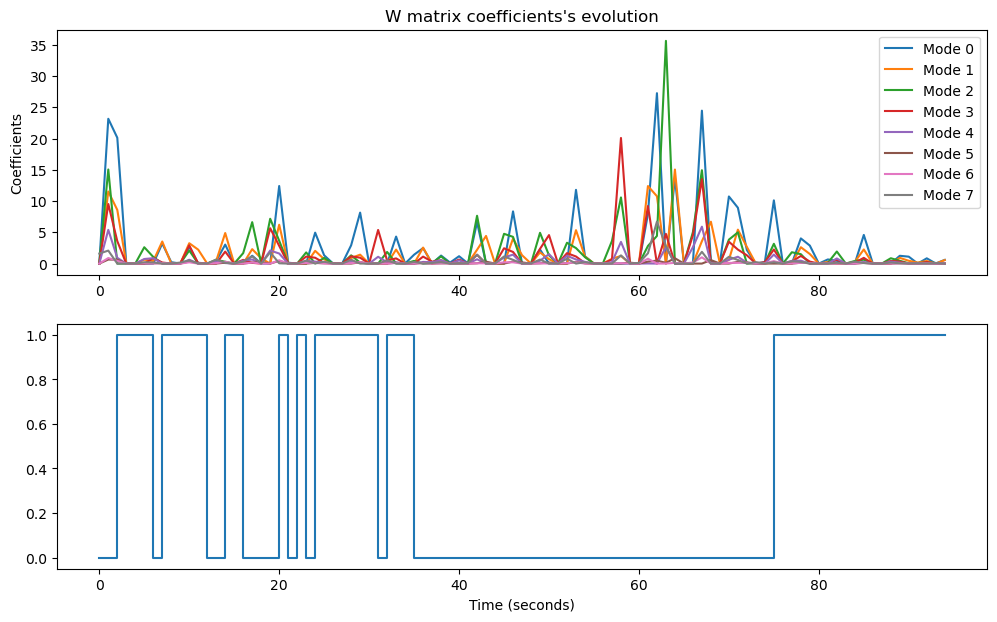

In [39]:
fig, axs = plt.subplots(2,1, figsize=(12,7))

axs[0].plot(W[5:100])
axs[0].set_ylabel("Coefficients")
axs[0].set_title("W matrix coefficients's evolution")
axs[0].legend(["Mode {}".format(i) for i in range(n_components)])

_, target_data = load_train_data(set=0)
axs[1].step(range(len(target_data[0][5:100])), target_data[0][5:100])
axs[1].set_xlabel("Time (seconds)")

plt.show()

## Test

In [5]:
test_df = get_testing_input_data_channel_parallel()

Processing channel n°0
Processing channel n°1
Processing channel n°2
Processing channel n°3
Processing channel n°4
112615 windows to compute...


Parallel feature extraction: 100%|██████████| 112615/112615 [06:13<00:00, 301.28it/s]


In [6]:
test_df.to_csv("test_df_all_data2.csv", index=False, sep=",")

In [135]:
test_df = pd.read_csv("test_df_all_data.csv", sep=",")

In [344]:
test_df = test_df.drop(columns=cols_to_drop)

In [440]:
test_df = test_df[cols_to_keep]

In [169]:
# Mélanger les données X et les labels y
X_shuffled, y_shuffled = shuffle(X_boot, y_boot, random_state=42)

In [30]:
test_df

,std,var,amplitude,skewness,kurtosis,min,max,mean,median,amplitude_speed,...,cov_with_others,euclidean_distance_with_others,NMF_mode_0,NMF_mode_1,NMF_mode_2,NMF_mode_3,NMF_mode_4,NMF_mode_5,NMF_mode_6,NMF_mode_7
0,305563.566219,9.336909e+10,1.293642e+06,0.434145,-0.754239,-406754.195074,886887.698664,131806.795929,30733.996248,269420.758627,...,8.107981e+10,3.485089e+06,4529.116993,3366.115912,0.000000,2638.063267,0.000000,277.483043,0.000000,0.000000
1,166275.029007,2.764739e+10,5.420851e+05,0.189727,-1.307648,-662403.469620,-120318.364206,-441772.748185,-464522.420571,23212.059563,...,1.652538e+10,5.403360e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,168869.992027,2.851707e+10,5.490227e+05,-0.683280,-0.856411,-119488.903302,429533.782429,253695.768809,307967.806213,4593.129876,...,1.592927e+10,3.711623e+06,4236.598164,1011.965809,3307.721478,0.000000,662.695145,0.000000,261.093525,453.283879
3,126961.292996,1.611917e+10,4.112532e+05,-0.286073,-1.238278,14477.109408,425730.310322,252924.677431,269785.744831,3364.150882,...,7.350564e+09,2.660078e+06,6277.189682,3433.432476,993.271470,1813.334522,513.718338,178.884035,135.324729,22.061236
4,77381.358953,5.987875e+09,2.566060e+05,0.659431,-0.863531,-242423.297544,14182.710428,-158807.364280,-181885.649708,3412.434631,...,4.160738e+09,2.270516e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.086951,0.000000,0.004957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112610,151.369836,2.291283e+04,7.154611e+02,-0.052191,-0.651129,-459.762742,255.698394,-81.365569,-77.702302,400.478870,...,-2.723142e+04,1.168663e+04,0.057677,0.000000,0.513615,0.005574,0.035755,0.000000,0.044028,0.064851
112611,9971.037979,9.942160e+07,5.142117e+04,1.302222,2.498350,-18269.123450,33152.050150,-1290.677106,-48.293951,4050.110702,...,1.981946e+07,1.852814e+05,0.000000,0.715138,0.000000,0.000000,4.491280,0.051466,16.166551,0.000000
112612,10235.685494,1.047693e+08,1.207256e+05,6.827926,57.484353,-18302.290095,102423.273679,1003.273907,495.097742,51503.674741,...,3.245900e+07,2.066138e+05,201.305863,25.754792,19.607361,0.000000,0.000000,0.085387,0.258589,2.926844
112613,1916.322929,3.672294e+06,6.946794e+03,-0.554792,-0.774415,-2076.078596,4870.715861,2266.579162,2693.826644,369.217238,...,1.829069e+06,3.181814e+04,70.623402,46.039734,1.659428,19.554356,4.982978,1.287978,1.412591,0.000000


# Variables selection

In [189]:
df = pd.concat([X,y], axis=1)

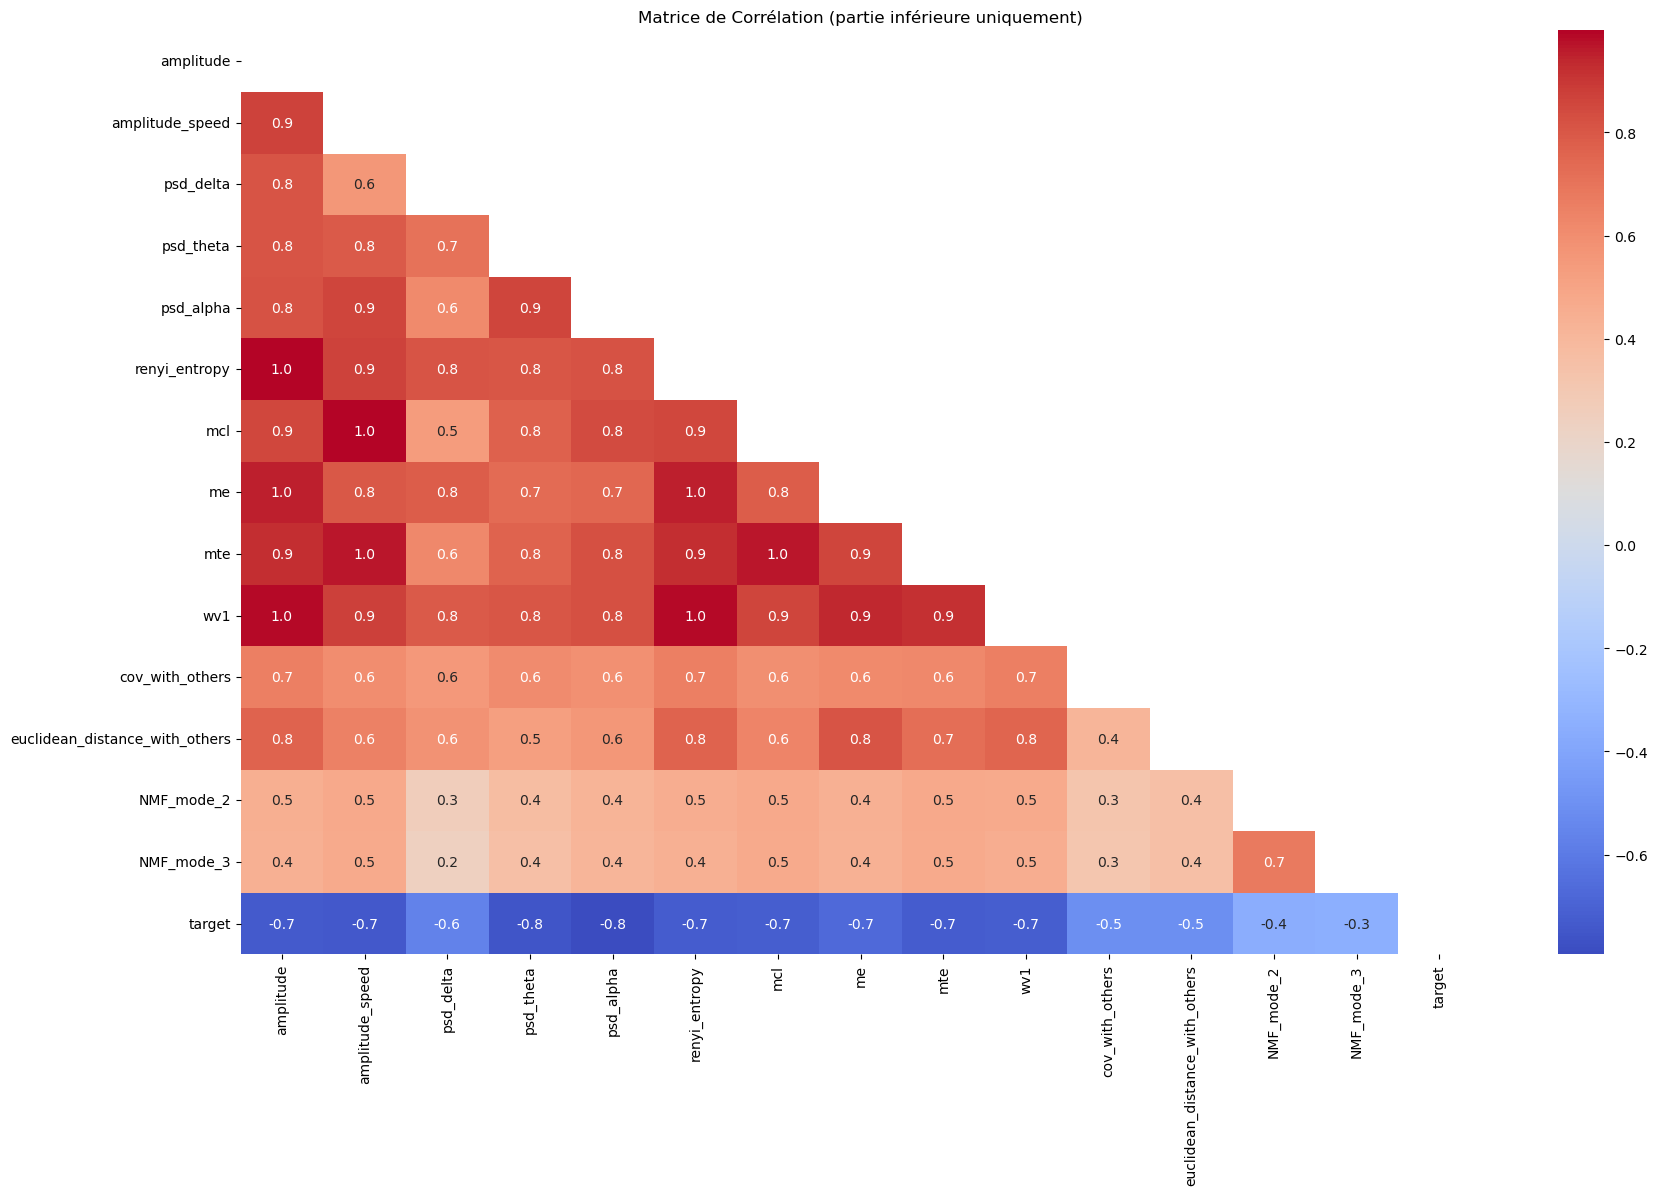

In [190]:
# Calcul de la matrice de corrélation
correlation_matrix = df.corr(method="spearman")

# Créer un masque pour cacher la partie supérieure
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Affichage avec une heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Matrice de Corrélation (partie inférieure uniquement)")
plt.show()

In [ ]:
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
model.fit(X, y)

# Créer un explainer pour le modèle
explainer = shap.TreeExplainer(model, approximate=True)

# Calculer les valeurs SHAP pour un sous-ensemble des données
shap_values = explainer.shap_values(X[:1000])

# Résumé pour toutes les données
shap.summary_plot(shap_values[:,:,0], X[:1000], feature_names=X.columns.tolist(), max_display=30)

In [143]:
def compute_fisher_scores(X, y, feature_names):
    """
    Calcule les F-scores et p-values pour chaque variable, 
    et retourne un DataFrame trié par F-score décroissant.
    
    Paramètres :
    - X : ndarray (n_samples, n_features) - Données d'entrée.
    - y : ndarray (n_samples,) - Labels de classe.
    - feature_names : list[str] - Noms des colonnes correspondant aux variables dans X.
    
    Retourne :
    - df_sorted : DataFrame - Contient les noms des variables, leurs F-scores et p-values, trié par F-score.
    """
    # Calculer les F-scores et p-values
    f_scores, p_values = f_classif(X, y)
    
    # Créer un DataFrame avec les résultats
    df = pd.DataFrame({
        'Variable': feature_names,
        'F-Score': f_scores,
        'p-Value': p_values
    })
    
    # Trier les variables par F-score décroissant
    df_sorted = df.sort_values(by='F-Score', ascending=False).reset_index(drop=True)
    
    return df_sorted

In [144]:
feature_names = X.columns.tolist()
df_fisher_scores = compute_fisher_scores(X, y, feature_names)

In [85]:
def compute_fisher_scores_with_half_mean_threshold(X, y, feature_names):
    """
    Calcule les F-scores et p-values pour chaque variable, 
    filtre celles qui ont un F-score inférieur à la moitié de la moyenne,
    et retourne un DataFrame trié par F-score décroissant.
    
    Paramètres :
    - X : ndarray (n_samples, n_features) - Données d'entrée.
    - y : ndarray (n_samples,) - Labels de classe.
    - feature_names : list[str] - Noms des colonnes correspondant aux variables dans X.
    
    Retourne :
    - df_filtered : DataFrame - Contient les variables avec un F-score supérieur au seuil.
    """
    # Calculer les F-scores et p-values
    f_scores, p_values = f_classif(X, y)
    
    # Calculer le seuil comme la moitié de la moyenne des F-scores
    threshold = f_scores.mean() / 2
    print(f"Seuil (moitié de la moyenne des F-scores) : {threshold}")
    
    # Identifier les variables à retenir et celles à exclure
    retained_indices = f_scores >= threshold
    excluded_indices = f_scores < threshold
    excluded_variables = [feature_names[i] for i in range(len(f_scores)) if excluded_indices[i]]
    
    # Afficher les noms des variables exclues
    if excluded_variables:
        print("Variables exclues (F-score < seuil) :", excluded_variables)
    else:
        print("Aucune variable n'a été exclue.")
    
    # Créer un DataFrame avec les variables retenues
    df_filtered = pd.DataFrame({
        'Variable': [feature_names[i] for i in range(len(f_scores)) if retained_indices[i]],
        'F-Score': [f_scores[i] for i in range(len(f_scores)) if retained_indices[i]],
        'p-Value': [p_values[i] for i in range(len(f_scores)) if retained_indices[i]],
    }).sort_values(by='F-Score', ascending=False).reset_index(drop=True)
    
    return df_filtered

In [86]:
feature_names = X.columns.tolist()
df_fisher_scores = compute_fisher_scores_with_half_mean_threshold(X, y, feature_names)

Seuil (moitié de la moyenne des F-scores) : 7307.404685021812
Variables exclues (F-score < seuil) : ['std', 'var', 'amplitude', 'skewness', 'kurtosis', 'min', 'max', 'mean', 'median', 'amplitude_speed', 'avg_speed', 'max_speed', 'min_speed', 'energy', 'psd_delta', 'psd_theta', 'psd_alpha', 'psd_beta', 'D3-1', 'D3-2', 'D3-3', 'D4-2', 'A5-1', 'A5-2', 'A5-3', 'hc', 'me', 'mte', 'wv1', 'wv2', 'wv3', 'wv4', 'corr_with_others', 'cov_with_others', 'euclidean_distance_with_others', 'NMF_mode_0', 'NMF_mode_1', 'NMF_mode_2', 'NMF_mode_3', 'NMF_mode_4', 'NMF_mode_5', 'NMF_mode_6', 'NMF_mode_7']


In [145]:
df_fisher_scores["Variable"].tolist()

['renyi_entropy',
 'apen',
 'D3-4',
 'hm',
 'ha',
 'zc',
 'D4-4',
 'pfd',
 'D4-1',
 'D5-3',
 'D5-1',
 'D4-3',
 'hurst',
 'mcl',
 'pen',
 'D5-2',
 'spen',
 'amplitude_speed',
 'min_speed',
 'euclidean_distance_with_others',
 'A5-1',
 'max_speed',
 'D4-2',
 'std',
 'corr_with_others',
 'A5-3',
 'amplitude',
 'D3-1',
 'max',
 'min',
 'wv4',
 'D3-3',
 'NMF_mode_2',
 'NMF_mode_7',
 'NMF_mode_5',
 'NMF_mode_4',
 'NMF_mode_3',
 'NMF_mode_1',
 'NMF_mode_6',
 'NMF_mode_0',
 'skewness',
 'kurtosis',
 'A5-2',
 'energy',
 'me',
 'mte',
 'var',
 'wv1',
 'psd_delta',
 'cov_with_others',
 'D3-2',
 'psd_alpha',
 'hc',
 'wv2',
 'psd_beta',
 'psd_theta',
 'wv3',
 'mean',
 'median',
 'avg_speed']

In [146]:
f_scores = df_fisher_scores["Variable"].tolist()

# Data augmentation

In [198]:
# Bootstrap : tirer un échantillon avec remplacement
bootstrap_sample_X = resample(X, n_samples=40000, replace=True)
bootstrap_sample_y = resample(y, n_samples=40000, replace=True)

X_boot = pd.concat([X, bootstrap_sample_X], axis=0)
y_boot = pd.concat([y, bootstrap_sample_y], axis=0)


# Search kappa

In [147]:
def selection_recursive(lst, idx=0, result=None):
    if result is None:
        result = []
    
    if idx < len(lst):
        # Ajoute l'élément courant à la liste
        result.append(lst[:idx+1])
        # Appel récursif avec l'index suivant
        selection_recursive(lst, idx + 1, result)
    
    return result

In [148]:
result = selection_recursive(f_scores)

In [170]:
all_kappa_scores = []

for i in tqdm(range(len(result)), desc="Features treatment"):
    cols_to_keep = result[i]
    # Mélanger les données X et les labels y
    X_shuffled, y_shuffled = shuffle(X_boot[cols_to_keep], y_boot, random_state=42)

    # Initialiser le modèle
    model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)

    # Initialiser la K-fold avec StratifiedKFold pour équilibrer les classes
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Liste pour stocker les scores kappa de chaque fold

    kappa_scores = []
    # Boucle sur les splits de K-fold
    for train_index, val_index in kf.split(X_shuffled, y_shuffled):
        X_train_k, X_val = X_shuffled.iloc[train_index], X_shuffled.iloc[val_index]
        y_train_k, y_val = y_shuffled.iloc[train_index], y_shuffled.iloc[val_index]  # Utiliser iloc ici
        
        # Entraîner le modèle
        model.fit(X_train_k, y_train_k)
        
        # Prédictions sur l'ensemble de validation
        y_pred = model.predict(X_val)
        
        # Calculer le score kappa
        kappa = cohen_kappa_score(y_val, y_pred)
        kappa_scores.append(kappa)

    all_kappa_scores.append(np.mean(kappa_scores))

Features treatment: 100%|██████████| 60/60 [27:01<00:00, 27.02s/it]


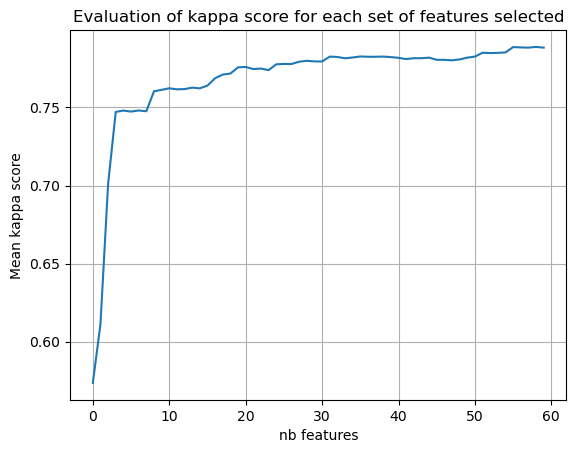

In [171]:
plt.plot(all_kappa_scores)
plt.xlabel("nb features")
plt.ylabel("Mean kappa score")
plt.title("Evaluation of kappa score for each set of features selected")
plt.grid()
plt.show()

# Model

In [200]:
# Initialiser le modèle Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, oob_score=True, max_depth=10)

# Entraîner le modèle
rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)

OOB Score: 0.8973147499384552


In [28]:
from sklearn import set_config
set_config(display="text")

In [122]:
# Créer le classificateur XGBoost
model = XGBClassifier(n_estimators=25, objective="binary:logistic", max_depth=5, learning_rate=0.01, eval_metric='logloss', random_state=42)

# Entraîner le modèle
model.fit(X_shuffled, y_shuffled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=25,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [201]:
y_pred = rf.predict(X_test).tolist()  # Pour une classification binaire
y_pred_train = rf.predict(X_train).tolist()

# Évaluation du modèle
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")
#print("OOB Score:", rf.oob_score_)

Train Accuracy: 0.9052919120571137

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     84837
           1       0.92      0.92      0.92    126391

    accuracy                           0.91    211228
   macro avg       0.90      0.90      0.90    211228
weighted avg       0.91      0.91      0.91    211228

Test Accuracy: 0.8986821611232008

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87     36463
           1       0.92      0.91      0.92     54064

    accuracy                           0.90     90527
   macro avg       0.89      0.89      0.89     90527
weighted avg       0.90      0.90      0.90     90527

Score Kappa : 0.7894991299566259


In [211]:
# Initialiser le modèle Random Forest
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)

# Créer un KFold (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Évaluer avec cross-validation
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

print("Scores pour chaque fold :", scores)
print("Moyenne des scores :", scores.mean())
print(f"Écart type des scores :", scores.std())

Scores pour chaque fold : [0.89885433 0.89793117 0.89748142 0.89923068 0.89627175]
Moyenne des scores : 0.8979538678332923
Écart type des scores : 0.0010482677440475923


In [210]:
# Initialiser le modèle
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
# Initialiser la K-fold avec StratifiedKFold pour équilibrer les classes
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Liste pour stocker les scores kappa de chaque fold
kappa_scores = []
accuracy_scores = []

# Boucle sur les splits de K-fold
for train_index, val_index in kf.split(X_train, y_train):
    X_train_k, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_k, y_val = y_train.iloc[train_index], y_train.iloc[val_index]  # Utiliser iloc ici
    
    # Entraîner le modèle
    model.fit(X_train_k, y_train_k)
    
    # Prédictions sur l'ensemble de validation
    y_pred = model.predict(X_val)
    
    # Calculer le score kappa
    kappa = cohen_kappa_score(y_val, y_pred)
    kappa_scores.append(kappa)

    accuracy_scores.append(accuracy_score(y_val, y_pred))

# Moyenne et écart type des scores kappa
print(f"Score kappa moyen : {np.mean(kappa_scores):.4f}")
print(f"Écart type du score kappa : {np.std(kappa_scores):.4f}")

# Moyenne et écart type des scores kappa
print(f"Accuracy moyen : {np.mean(accuracy_scores):.4f}")
print(f"Écart type accuracy : {np.std(accuracy_scores):.4f}")

Score kappa moyen : 0.7880
Écart type du score kappa : 0.0058
Accuracy moyen : 0.8981
Écart type accuracy : 0.0027


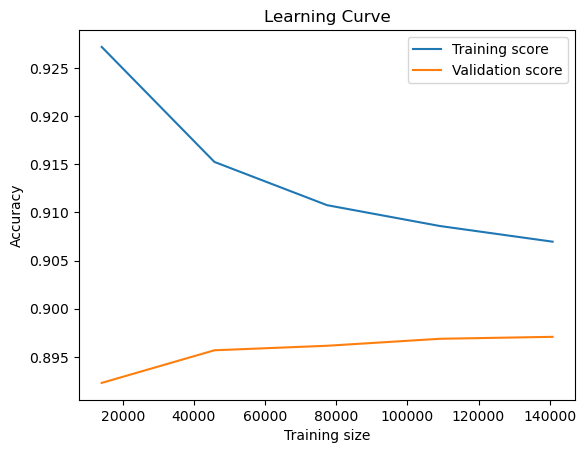

In [177]:
rf_plot = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
plot_learning_curve(rf_plot, X_train, y_train)

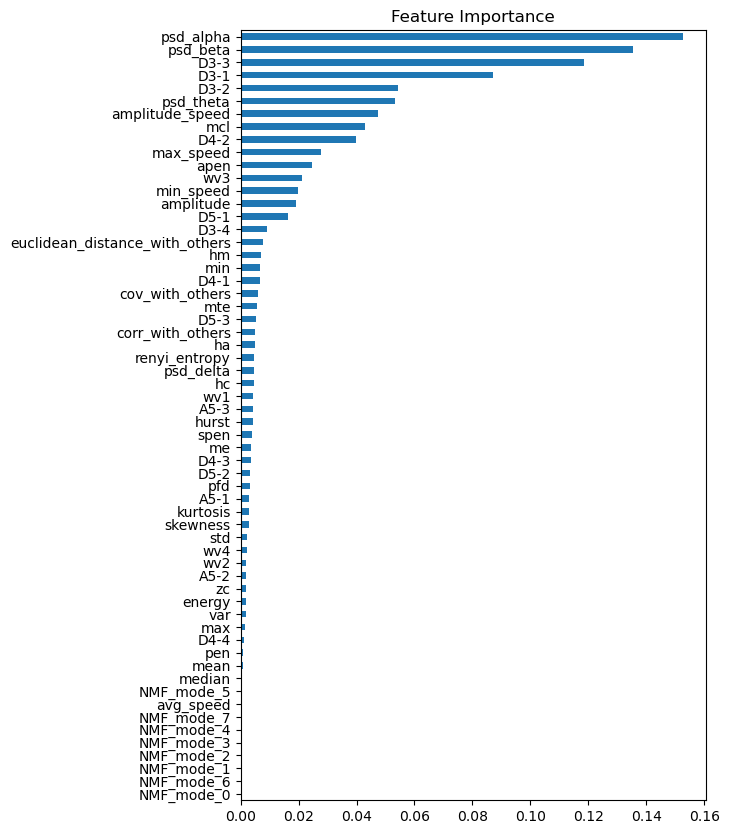

In [180]:
# Importance des features
plt.figure(figsize=(6,10))
importance = pd.Series(rf.feature_importances_, index=X_train.columns.tolist())
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

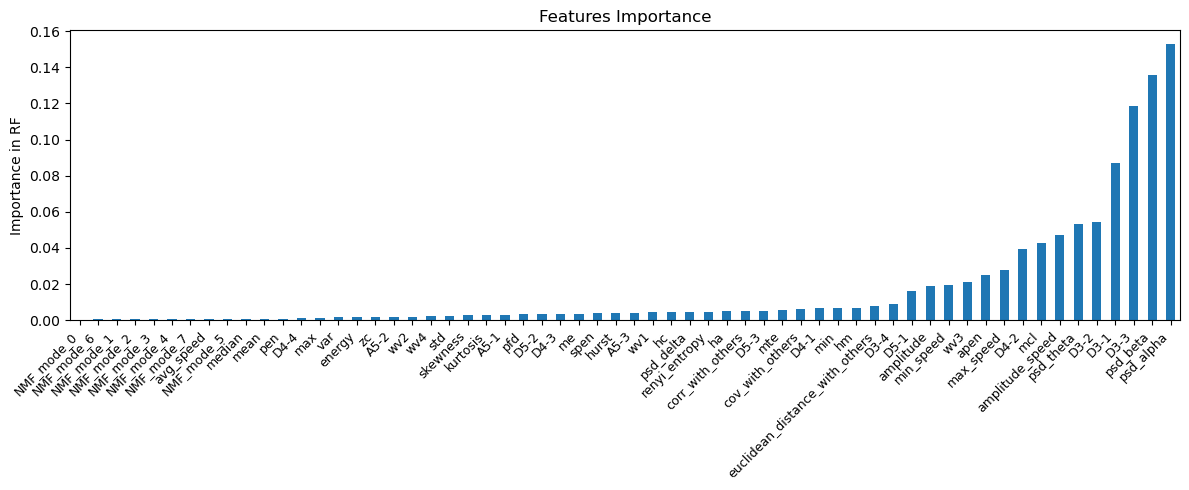

In [196]:
# Feature Importance
plt.figure(figsize=(12,5))  # Ajuste la taille du graphique
importance = pd.Series(rf.feature_importances_, index=X_train.columns.tolist())
importance.sort_values().plot(kind="bar")  # 'bar' pour un graphique vertical
plt.title("Features Importance")
plt.ylabel("Importance in RF")

# Incliner les labels de l'axe des x à 45° et réduire la taille de la police
plt.xticks(rotation=45, ha="right", fontsize=9)  # 'ha' pour l'alignement horizontal des labels

# Ajuster automatiquement les marges
plt.tight_layout()

plt.show()

## Results

#### Résultats de Modèle (n_estimators=400, max_depth=30)

Précision sur l'entraînement
**Train Accuracy**: 1.0
**Test Accuracy**: 0.9539012059546398

Rapport de Classification
| Classe | Précision | Rappel | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| 0      | 0.94      | 0.95   | 0.94     | 31485   |
| 1      | 0.96      | 0.96   | 0.96     | 47042   |

**Exactitude globale (accuracy)**: 0.95  
**Moyenne macro (macro avg)**: 0.95 (Précision), 0.95 (Rappel), 0.95 (F1-Score)  
**Moyenne pondérée (weighted avg)**: 0.95 (Précision), 0.95 (Rappel), 0.95 (F1-Score)

Score Kappa
**Score Kappa**: <span style="color:red">0.9041246709971473</span>

#### Résultats du modèle (n_estimators=300, max_depth=30)

Précision sur les ensembles
- **Train Accuracy**: 1.0  
- **Test Accuracy**: 0.9536  

Rapport de classification
| Classe | Précision | Rappel | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| 0      | 0.94      | 0.95   | 0.94     | 31,485  |
| 1      | 0.96      | 0.96   | 0.96     | 47,042  |

| Métrique        | Valeur |
|------------------|--------|
| **Exactitude**   | 0.95   |
| **Macro Moyenne**| 0.95   |
| **Moyenne Pondérée** | 0.95   |

Score Kappa
- **Score Kappa**: 0.9035

#### Model Performance (n_estimators=200, max_depth=50)

Train Accuracy
- **Train Accuracy:** 1.0
- **Test Accuracy:** 0.9533281546474461

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.95   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.9029476181891937

#### Model Performance (n_estimators=300, max_depth=50)

Train Accuracy
- **Train Accuracy:** 1.0
- **Test Accuracy:** 0.9534937028028576

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.95   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.9032913621291838


#### Model Performance (n_estimators=300, max_depth=20)

Train Accuracy
- **Train Accuracy:** 0.9958739930578296
- **Test Accuracy:** 0.9530989341245686

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.94   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.902470962562292

## Gridsearch

In [ ]:
# Définir les hyperparamètres à tester
param_grid = {
    'max_depth': [10, 20, 30, 40, 50, 70, 100, None],            # Profondeur maximale des arbres
    'n_estimators': [50, 100, 200, 250, 300]              # Nombre d'arbres dans la forêt
}

# Créer le modèle de Random Forest
rf = RandomForestClassifier(random_state=42)

# Définir GridSearchCV avec Cross-Validation (par défaut, k=5)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

# Lancer la recherche des meilleurs hyperparamètres
grid_search.fit(X_train, y_train)

# Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score : {grid_search.best_score_}")

# Tester sur le jeu de test
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Précision sur le jeu de test : {accuracy_score(y_test, y_pred)}")

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Score Kappa : {kappa_score}")

# OLS

In [152]:
# Ajouter une constante (biais) à X (important pour l'OLS)
X_cst = sm.add_constant(X_train.reset_index(drop=True))

# Régression OLS
model = sm.OLS(y_train.reset_index(drop=True), X_cst)  # Y est la variable cible, X les caractéristiques (avec constante)
results = model.fit()  # Ajuster le modèle

# Afficher le résumé des statistiques du modèle
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                      -1.492
Model:                            OLS   Adj. R-squared:                 -1.492
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 10 Jan 2025   Prob (F-statistic):                nan
Time:                        15:37:14   Log-Likelihood:            -2.4553e+05
No. Observations:              211228   AIC:                         4.911e+05
Df Residuals:                  211227   BIC:                         4.911e+05
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [4]:
# Ajouter une constante (biais) à X (important pour l'OLS)
X_cst = sm.add_constant(X_train)

# Régression OLS
model = sm.OLS(y_train, X_cst)  # Y est la variable cible, X les caractéristiques (avec constante)
results = model.fit()  # Ajuster le modèle

# Afficher le résumé des statistiques du modèle
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     740.0
Date:                Wed, 08 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:18:13   Log-Likelihood:            -1.2407e+05
No. Observations:              183228   AIC:                         2.482e+05
Df Residuals:                  183212   BIC:                         2.483e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6185      0.001    516.128      0.0

# Submission

In [66]:
def format_array_to_target_format(array, record_number, nb_points):

    formatted_target = []
    for i in range(5):
        channel_encoding = (i + 1) * 100000
        record_number_encoding = record_number * 1000000
        for j in range(nb_points):
            formatted_target.append(
                {
                    "identifier": record_number_encoding + channel_encoding + j,
                    "target": array[i][j],
                }
            )
    return formatted_target

In [138]:
set_4_df = pd.DataFrame()
size_channel_set_4 = 13204

set_5_df = pd.DataFrame()
size_channel_set_5 = 9319

set_4_idx = 0
set_5_idx = size_channel_set_4

for c in range(5):
    #print(test_df[set_4_idx:set_4_idx+size_channel_set_4])
    set_4_df = pd.concat([set_4_df, test_df[set_4_idx:set_4_idx+size_channel_set_4]])

    #print(test_df[set_5_idx:set_5_idx+size_channel_set_5])
    set_5_df = pd.concat([set_5_df, test_df[set_5_idx:set_5_idx+size_channel_set_5]])

    set_4_idx += size_channel_set_4 + size_channel_set_5
    set_5_idx += size_channel_set_4 + size_channel_set_5

new_test_df = pd.concat([set_4_df, set_5_df])
new_test_df.reset_index(drop=True, inplace=True)

In [139]:
results = []

# Set 4
X_test_4 = new_test_df[:66020]
preds = rf.predict(X_test_4)
sublists = [preds[i:i + 13204] for i in range(0, len(preds), 13204)]

formatted_preds = format_array_to_target_format(sublists, 4, 13204)
results.extend(formatted_preds)

# Set 5
X_test_5 = new_test_df[66020:]
preds = rf.predict(X_test_5)
sublists = [preds[i:i + 9319] for i in range(0, len(preds), 9319)]

formatted_preds = format_array_to_target_format(sublists, 5, 9319)
results.extend(formatted_preds)

df_results = pd.DataFrame(results)
df_results.to_csv("../Results/my_submission_RandomForest_nest_50_mdepth_10_all_variables_nmf_channels_d5_shuff_boot_100.csv", index = False)

In [364]:
df_target = pd.read_csv("../Results/my_submission_RandomForest_nmf_nest_200_mdepth_10_all_variables_and_channels.csv")

In [365]:
df_target["target"].value_counts()

target
0    66310
1    46305
Name: count, dtype: int64

In [140]:
df_results["target"].value_counts()

target
0    66800
1    45815
Name: count, dtype: int64